<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/Rainfall_Investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Collection


In [1]:
import pandas as pd
file_id = '1ha6-YJq02MBaSPgTSPg3kTqXNI0TYzqi'
url = 'https://drive.google.com/uc?id={}'.format(file_id)
data = pd.read_csv(url)

### Data processing

In [2]:
data.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,True
1,1948-01-02,0.59,45,36,True
2,1948-01-03,0.42,45,35,True
3,1948-01-04,0.31,45,34,True
4,1948-01-05,0.17,45,32,True


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25551 entries, 0 to 25550
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    25551 non-null  object 
 1   PRCP    25548 non-null  float64
 2   TMAX    25551 non-null  int64  
 3   TMIN    25551 non-null  int64  
 4   RAIN    25548 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 998.2+ KB


In [4]:
data.describe()

,PRCP,TMAX,TMIN
count,25548.000000,25551.000000,25551.000000
mean,0.106222,59.544206,44.514226
std,0.239031,12.772984,8.892836
min,0.000000,4.000000,0.000000
25%,0.000000,50.000000,38.000000
50%,0.000000,58.000000,45.000000
75%,0.100000,69.000000,52.000000
max,5.020000,103.000000,71.000000


In [6]:
data.isnull().sum()

,0
DATE,0
PRCP,3
TMAX,0
TMIN,0
RAIN,3


In [8]:
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

,0
DATE,0
PRCP,0
TMAX,0
TMIN,0
RAIN,0


In [7]:
data.duplicated().sum()

np.int64(0)

### Data Formatting

In [10]:
#Changing columns to necessary data types
data = data.astype({"DATE" : "datetime64[ns]", "RAIN" : "int16"})

In [11]:
data.head()

,DATE,PRCP,TMAX,TMIN,RAIN
0,1948-01-01,0.47,51,42,1
1,1948-01-02,0.59,45,36,1
2,1948-01-03,0.42,45,35,1
3,1948-01-04,0.31,45,34,1
4,1948-01-05,0.17,45,32,1


### Exploratory Data Analysis

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
#extract the MONTH from the DATE column and create a new month column
data["MONTH"] = data["DATE"].dt.month

#create aa pivot table
rainfall_pivot = data.pivot_table(index = ["RAIN"], columns = "MONTH", aggfunc = "size", fill_value = 0)

#select the row where RAIN is true
rainymonth_counter = rainfall_pivot.loc[1]

#extract the keys (months) and values (counters)
months = rainymonth_counter.index
counter = rainymonth_counter.values

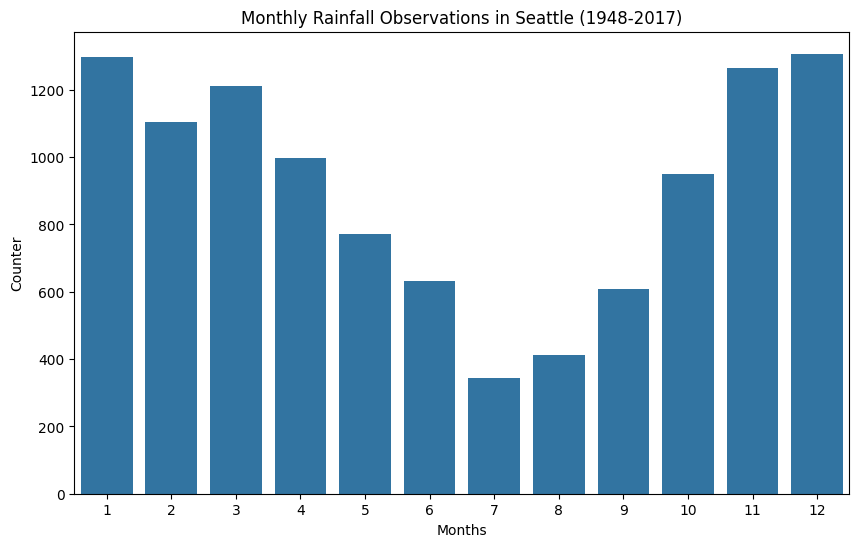

In [20]:
#create a bar plot using sns
plt.figure(figsize = (10, 6))
sns.barplot(x = months, y = counter)
plt.xlabel("Months")
plt.ylabel("Counter")
plt.title("Monthly Rainfall Observations in Seattle (1948-2017)")
plt.show()

Monthly Precipitation

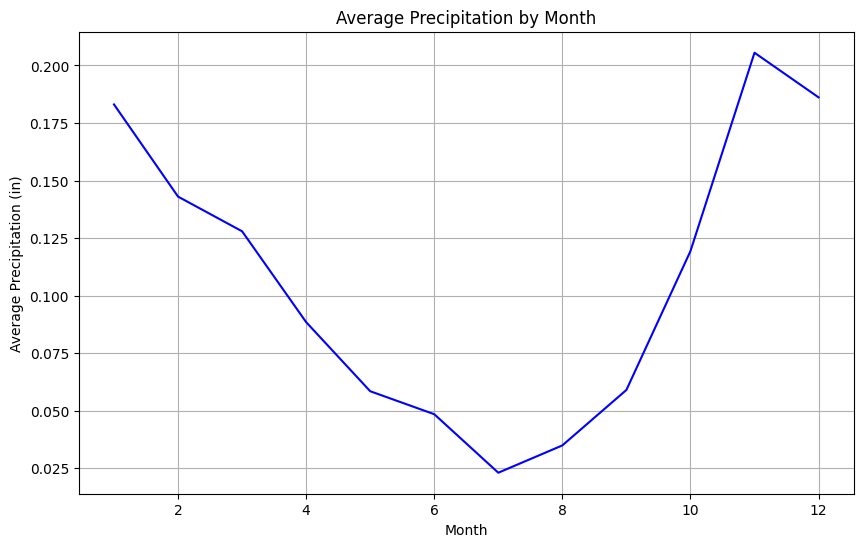

In [23]:
averageByMonth = data.groupby("MONTH")["PRCP"].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=averageByMonth, x='MONTH', y='PRCP', linewidth=1.5, color='blue')
plt.title('Average Precipitation by Month')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (in)')
plt.grid(True)
plt.show()

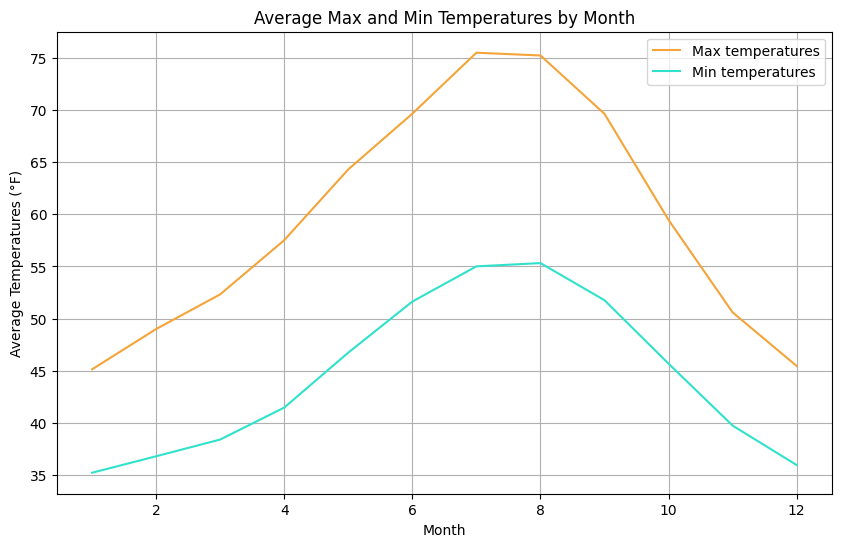

In [26]:
# Calculate the average maximum and minimum temperatures by month
averageByMonth = data.groupby('MONTH')[['TMAX', 'TMIN']].mean().reset_index()
# Create a line plot using Seaborn and Matplotlib
plt.figure(figsize=(10, 6))
sns.lineplot(data=averageByMonth, x='MONTH', y='TMAX', linewidth=1.5, color='#F4A438', label='Max temperatures')
sns.lineplot(data=averageByMonth, x='MONTH', y='TMIN', linewidth=1.5, color='#30E1CB', label='Min temperatures')
plt.title('Average Max and Min Temperatures by Month')
plt.xlabel('Month')
plt.ylabel('Average Temperatures (°F)')
plt.legend()
plt.grid(True)
plt.show()